# Understanding the Q-Q Plot

A Q-Q (Quantile-Quantile) plot checks whether a sample follows a theoretical distribution — most commonly the normal distribution. Each point represents one quantile of the sample vs the corresponding quantile of the theoretical distribution. If the distribution matches, the points fall on a straight diagonal line.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

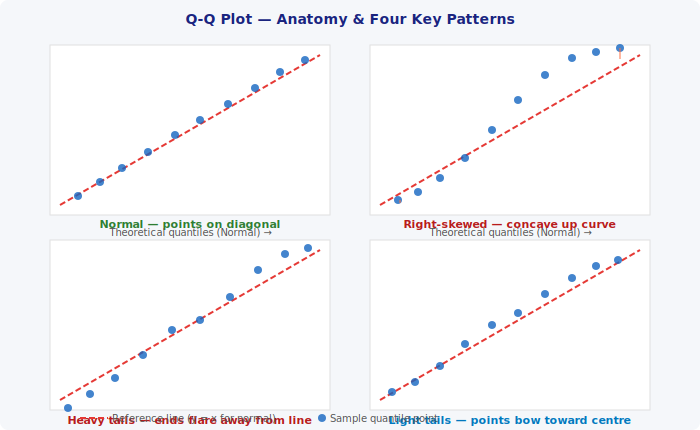

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="700" height="430"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="700" height="430" fill="#F5F7FA" rx="8"/>
  <text x="350" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Q-Q Plot — Anatomy &amp; Four Key Patterns</text>

  <!-- Four mini Q-Q plot panels in a 2x2 grid -->
  <!-- Panel origins: TL=(50,45) TR=(370,45) BL=(50,240) BR=(370,240) -->
  <!-- Each panel: 280x170 -->

  <!-- ── Panel 1: Normally distributed (points on diagonal) ── -->
  <rect x="50"  y="45" width="280" height="170" fill="white" stroke="#E0E0E0"/>
  <!-- Reference diagonal -->
  <line x1="60" y1="205" x2="320" y2="55" stroke="#E53935" stroke-width="2" stroke-dasharray="6,3"/>
  <!-- Points tightly on diagonal -->
  <circle cx="78"  cy="196" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="100" cy="182" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="122" cy="168" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="148" cy="152" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="175" cy="135" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="200" cy="120" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="228" cy="104" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="255" cy="88"  r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="280" cy="72"  r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="305" cy="60"  r="4" fill="#1565C0" opacity="0.8"/>
  <text x="190" y="228" text-anchor="middle" font-size="11" font-weight="bold" fill="#2E7D32">Normal — points on diagonal</text>

  <!-- ── Panel 2: Right-skewed (S-curve, high values above line) ── -->
  <rect x="370" y="45" width="280" height="170" fill="white" stroke="#E0E0E0"/>
  <line x1="380" y1="205" x2="640" y2="55" stroke="#E53935" stroke-width="2" stroke-dasharray="6,3"/>
  <!-- Points: S-curve — below line at left, above at right -->
  <circle cx="398" cy="200" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="418" cy="192" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="440" cy="178" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="465" cy="158" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="492" cy="130" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="518" cy="100" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="545" cy="75"  r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="572" cy="58"  r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="596" cy="52"  r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="620" cy="48"  r="4" fill="#1565C0" opacity="0.8"/>
  <!-- Deviation arrows -->
  <line x1="400" y1="200" x2="400" y2="203" stroke="#FF7043" stroke-width="1"/>
  <line x1="620" y1="48"  x2="620" y2="59"  stroke="#FF7043" stroke-width="1"/>
  <text x="510" y="228" text-anchor="middle" font-size="11" font-weight="bold" fill="#B71C1C">Right-skewed — concave up curve</text>

  <!-- ── Panel 3: Heavy tails (points flare out at both ends) ── -->
  <rect x="50"  y="240" width="280" height="170" fill="white" stroke="#E0E0E0"/>
  <line x1="60" y1="400" x2="320" y2="250" stroke="#E53935" stroke-width="2" stroke-dasharray="6,3"/>
  <!-- Points: below line on left, above on right -->
  <circle cx="68"  cy="408" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="90"  cy="394" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="115" cy="378" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="143" cy="355" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="172" cy="330" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="200" cy="320" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="230" cy="297" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="258" cy="270" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="285" cy="254" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="308" cy="248" r="4" fill="#1565C0" opacity="0.8"/>
  <text x="190" y="424" text-anchor="middle" font-size="11" font-weight="bold" fill="#B71C1C">Heavy tails — ends flare away from line</text>

  <!-- ── Panel 4: Light tails (points hug towards centre) ── -->
  <rect x="370" y="240" width="280" height="170" fill="white" stroke="#E0E0E0"/>
  <line x1="380" y1="400" x2="640" y2="250" stroke="#E53935" stroke-width="2" stroke-dasharray="6,3"/>
  <!-- Points: above line on left, below on right (S-shape inverted) -->
  <circle cx="392" cy="392" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="415" cy="382" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="440" cy="366" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="465" cy="344" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="492" cy="325" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="518" cy="313" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="545" cy="294" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="572" cy="278" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="596" cy="266" r="4" fill="#1565C0" opacity="0.8"/>
  <circle cx="618" cy="260" r="4" fill="#1565C0" opacity="0.8"/>
  <text x="510" y="424" text-anchor="middle" font-size="11" font-weight="bold" fill="#0277BD">Light tails — points bow toward centre</text>

  <!-- Global axis labels -->
  <text x="190" y="236" text-anchor="middle" font-size="10" fill="#555">Theoretical quantiles (Normal) →</text>
  <text x="510" y="236" text-anchor="middle" font-size="10" fill="#555">Theoretical quantiles (Normal) →</text>

  <!-- Reference line legend -->
  <line x1="80" y1="418" x2="108" y2="418" stroke="#E53935" stroke-width="2" stroke-dasharray="6,3"/>
  <text x="112" y="422" font-size="10" fill="#555">Reference line (y = x for normal)</text>
  <circle cx="322" cy="418" r="4" fill="#1565C0" opacity="0.8"/>
  <text x="330" y="422" font-size="10" fill="#555">Sample quantile point</text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Q-Q Plot

| Pattern | Shape | What it means |
|---|---|---|
| **Points on diagonal** | Straight line | Data matches the theoretical distribution (normal) |
| **Concave-up curve** | S-curve bending up | Right-skewed distribution |
| **Concave-down curve** | S-curve bending down | Left-skewed distribution |
| **Ends flare away** | Points shoot out at both ends | Heavy tails — more extreme values than normal |
| **Ends bow inward** | Points hug the centre | Light tails — fewer extreme values than normal |
| **Staircase pattern** | Flat horizontal sections | Discrete data (only a few distinct values) |

**Practical rule**: if points fall reasonably close to the diagonal (especially in the middle range), you can treat the data as approximately normal. Extreme deviations at the tails matter most for robust regression and confidence interval calculations.

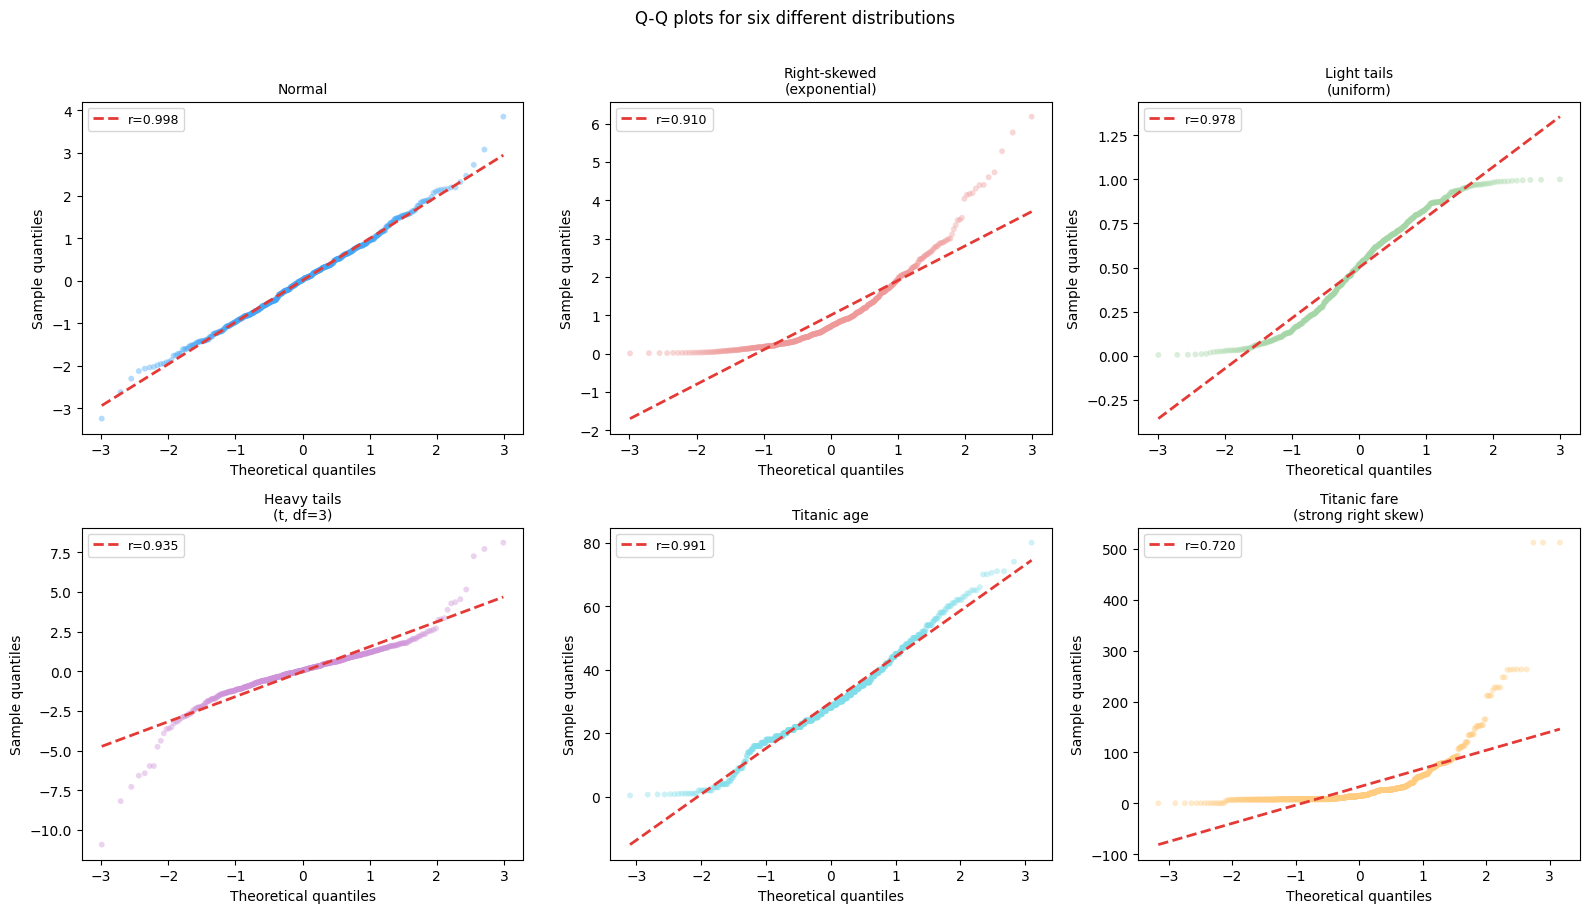

In [3]:
df = sns.load_dataset('titanic')
np.random.seed(42)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

distributions = [
    (np.random.normal(0,1,500),      'Normal',       '#42A5F5'),
    (np.random.exponential(1,500),   'Right-skewed\n(exponential)', '#EF9A9A'),
    (np.random.uniform(0,1,500),     'Light tails\n(uniform)', '#A5D6A7'),
    (np.random.standard_t(df=3,size=500), 'Heavy tails\n(t, df=3)', '#CE93D8'),
    (df['age'].dropna().values,      'Titanic age',  '#80DEEA'),
    (df['fare'].dropna().values,     'Titanic fare\n(strong right skew)', '#FFCC80'),
]

for ax, (data, label, color) in zip(axes.flat, distributions):
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, alpha=0.4, s=18, color=color, edgecolors='none')
    xline = np.array([osm.min(), osm.max()])
    ax.plot(xline, slope*xline + intercept, color='#E53935', linewidth=2,
            linestyle='--', label=f'r={r:.3f}')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Theoretical quantiles')
    ax.set_ylabel('Sample quantiles')
    ax.legend(fontsize=9)

plt.suptitle('Q-Q plots for six different distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Checking normality before applying parametric tests |
| **Points on diagonal** | Distribution matches theoretical (approximately normal) |
| **Tails above line** | Heavier tails than normal — outliers likely |
| **S-curve** | Skewed distribution |
| **Pairs with** | Histogram + KDE — Q-Q gives quantile precision; histogram gives shape intuition |
| **Formal test** | Add Shapiro-Wilk or Anderson-Darling for a p-value confirmation |